<a href="https://colab.research.google.com/github/CesarAr0504/Arredondo_Restrepo_Lab_Sen/blob/main/Practica_5_Biose%C3%B1ales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Introducción al análisis frecuencial de señales**

#**Integrantes:**
* Cesar Arredondo Gonzalez
* Alejandro Restrepo Molina

#**Resumen**

En la presente práctica se realizó un análisis frecuencial de señales biomédicas y sintéticas mediante el uso de la Transformada de Fourier y el periodograma de Welch en Python. Inicialmente, se generó una señal compuesta por tres componentes sinusoidales de 40 Hz, 80 Hz y 160 Hz, con el objetivo de estudiar su representación temporal y frecuencial. Posteriormente, se aplicaron técnicas de análisis espectral, filtrado en frecuencia y reconstrucción de señales mediante la Transformada Inversa de Fourier.

Adicionalmente, se realizó un análisis frecuencial sobre señales biomédicas reales, específicamente señales ECG y EEG, con el propósito de identificar componentes espectrales relevantes, presencia de ruido y diferencias fisiológicas entre sujetos sanos y pacientes con enfermedad de Parkinson.

Importación de librerias:

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.signal import welch
import matplotlib.gridspec as gridspec
from numpy.fft import fft, ifft, fftfreq

## **4.1**


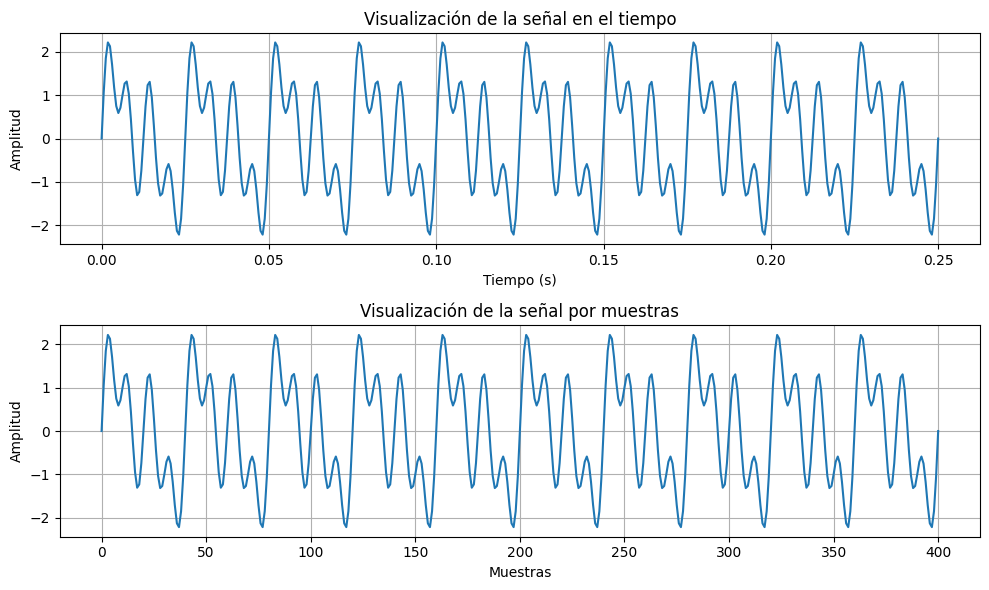

In [16]:
fs=160*10
Ts = 1/fs
T=1/40 #La frecuencia resultante será su M.C.M = 40, T=1/40 seg
n=T/Ts
t=np.arange(0,10*T+Ts,Ts)
sen1 = np.sin(2*np.pi*40*t)
sen2 = np.sin(2*np.pi*80*t)
sen3 = np.sin(2*np.pi*160*t)
muestras = np.arange(len(t))
signal = sen1+sen2+sen3
plt.figure(figsize=(10, 6))
plt.subplot(2,1,1)
plt.plot(t,signal)
plt.xlabel("Tiempo (s)")
plt.title("Visualización de la señal en el tiempo")
plt.ylabel("Amplitud")
plt.grid()
plt.subplot(2,1,2)
plt.plot(muestras,signal)
plt.xlabel("Muestras")
plt.title("Visualización de la señal por muestras")
plt.ylabel("Amplitud")
plt.tight_layout()
plt.grid()
plt.show()

##**4.2**

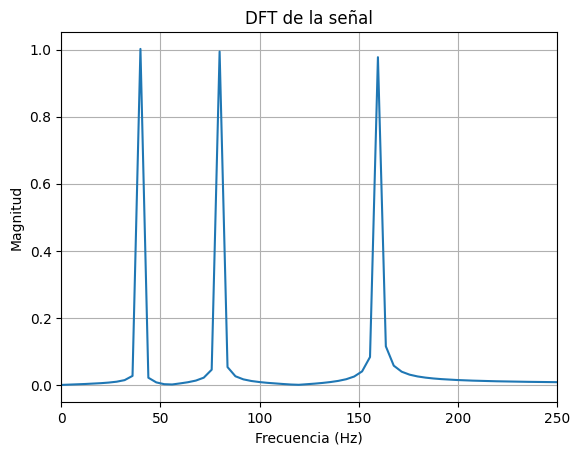

In [17]:
N=len(signal)
yf=np.fft.fft(signal)
xf=np.fft.fftfreq(N,Ts)[:N//2]
plt.plot(xf,2/N*np.abs(yf[:N//2]))

plt.xlabel("Frecuencia (Hz)")
plt.title("DFT de la señal")
plt.ylabel("Magnitud")
plt.grid()
plt.xlim(0,250)
plt.show()

##**4.3**

La función para calcular la transformada inversa de Fourier, la cual en seria el calculo de la señal original a partir de su transformada de fourier, la podemos encontrar en la libreria Numpy como np.fft.ifft()

documentación: https://numpy.org/doc/2.1/reference/generated/numpy.fft.ifft.html

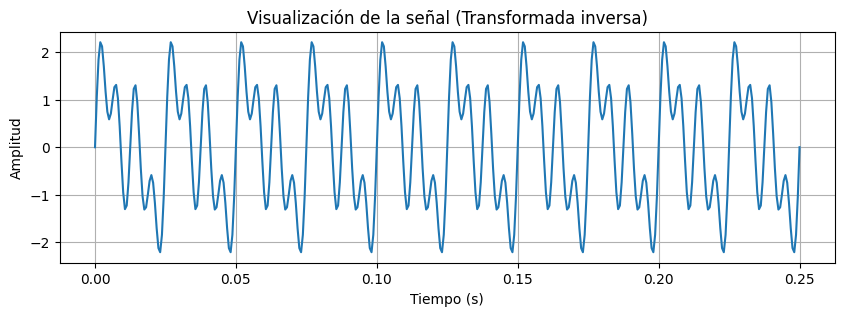

In [18]:
#Inversa
yf_inversa=np.fft.ifft(yf)
plt.figure(figsize=(10, 3))
plt.plot(t,np.real(yf_inversa))
plt.xlabel("Tiempo (s)")
plt.title("Visualización de la señal (Transformada inversa)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

##**4.4**

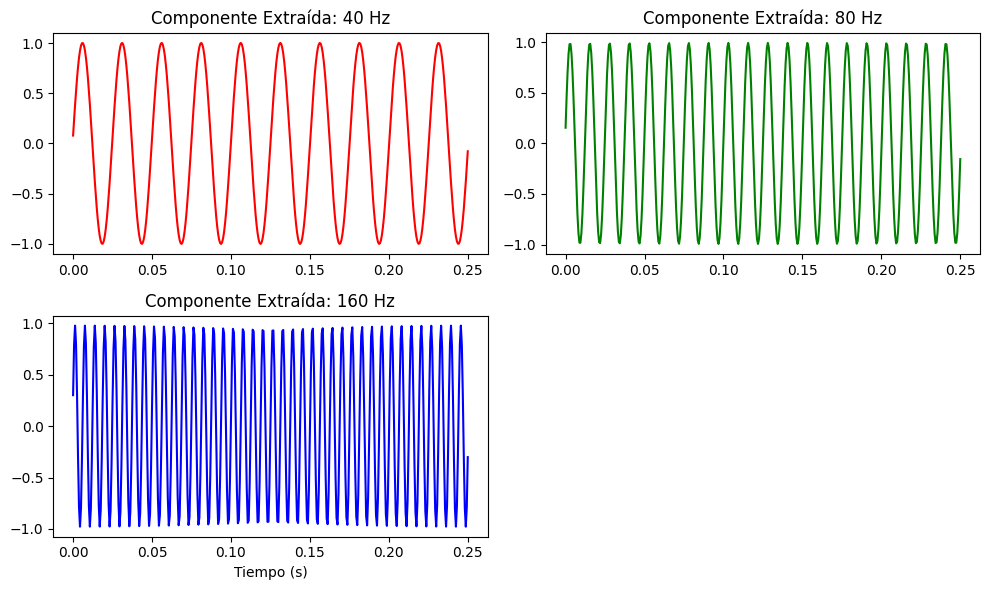

In [19]:
# Extrayendo componentes de la señal
N = len(signal)
yf = np.fft.fft(signal)
xf = np.fft.fftfreq(N, Ts) # Vector de frecuencias completo

# Extracción de componentes
def extraer_componente(f_objetivo, yf_full, xf_full, tolerancia=1):
    # Crear un vector de ceros del mismo tamaño que la DFT
    yf_filtrada = np.zeros(len(yf_full), dtype=complex)

    # Identificar los índices correspondientes a la frecuencia (positiva y negativa)
    # Es vital mantener la simetría para que el resultado sea real
    indices = np.where((np.abs(xf_full) >= f_objetivo - tolerancia) &
                       (np.abs(xf_full) <= f_objetivo + tolerancia))

    yf_filtrada[indices] = yf_full[indices]

    return np.fft.ifft(yf_filtrada).real

componente_40Hz = extraer_componente(40, yf, xf)
componente_80Hz = extraer_componente(80, yf, xf)
componente_160Hz = extraer_componente(160, yf, xf)

plt.figure(figsize=(10, 6))
plt.subplot(2,2,1)
plt.plot(t, componente_40Hz, color='r')
plt.title("Componente Extraída: 40 Hz")
plt.subplot(2,2,2)
plt.plot(t, componente_80Hz, color='g')
plt.title("Componente Extraída: 80 Hz")
plt.subplot(2,2,3)
plt.plot(t, componente_160Hz, color='b')
plt.xlabel("Tiempo (s)")
plt.title("Componente Extraída: 160 Hz")
plt.tight_layout()
plt.show()

##**4.5**

Muestras: 1250  |  Fs: 250 Hz  |  Duración: 5.00 s

Picos en el periodograma de Welch (f > 40 Hz):
  f = 59.6 Hz  |  PSD = 1.0742e-02


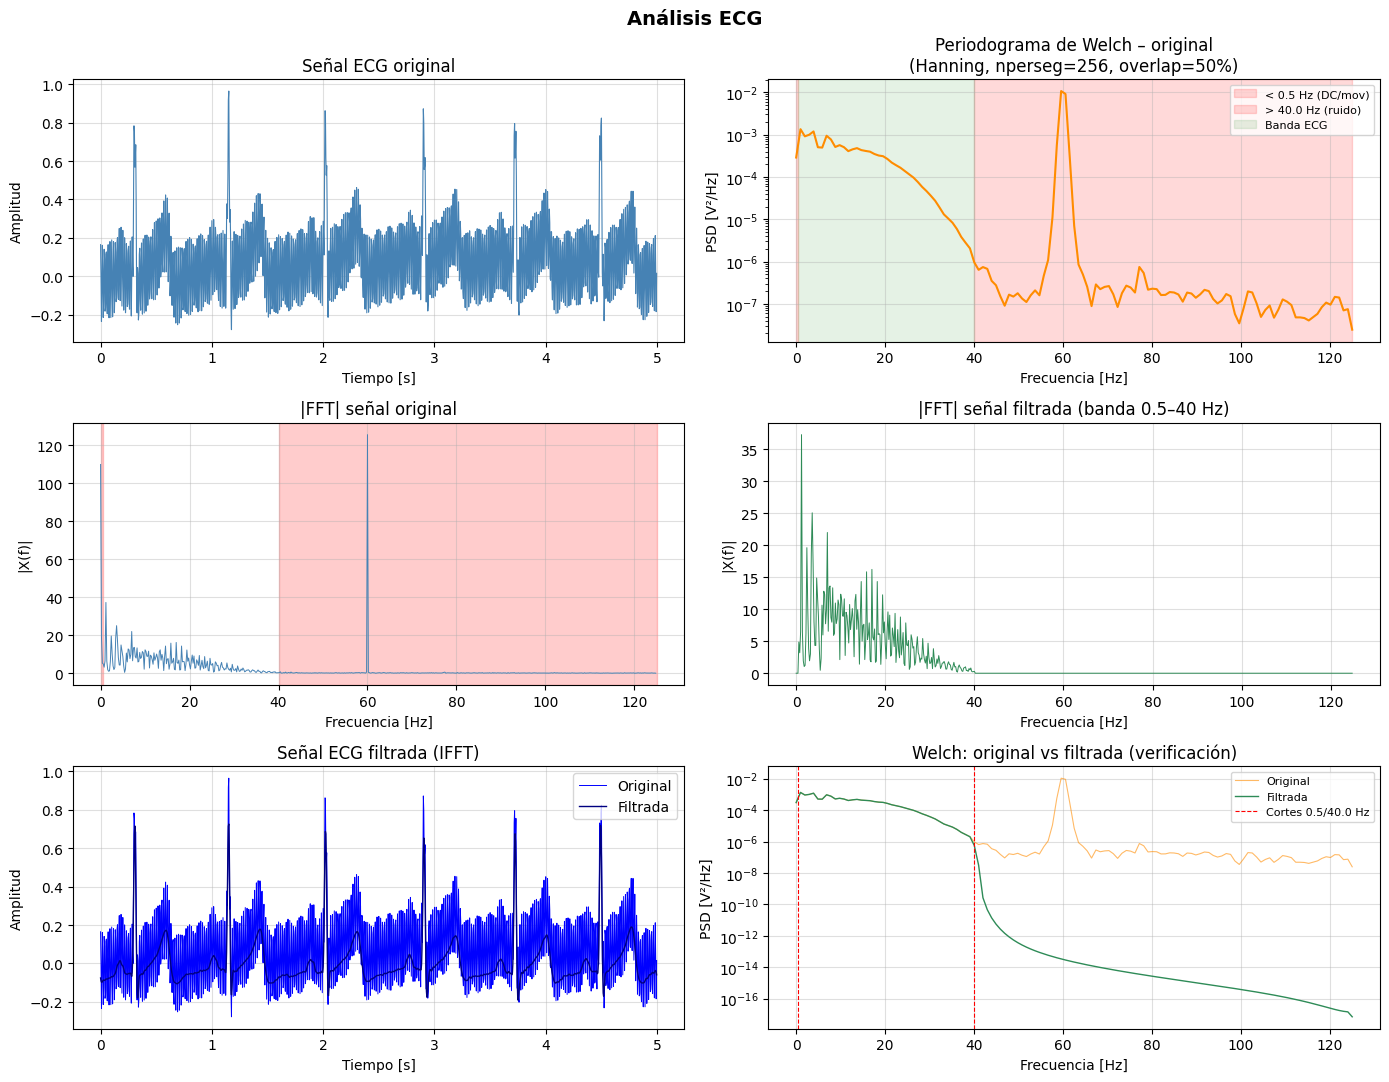

In [22]:
# Cargamos los datos
mat   = sio.loadmat('senecg.mat')
ecg   = mat['ECG'].flatten()          # señal ECG
Fs    = 250                            # frecuencia de muestreo [Hz]
N     = len(ecg)                       # número de muestras
t     = np.arange(N) / Fs

print(f"Muestras: {N}  |  Fs: {Fs} Hz  |  Duración: {N/Fs:.2f} s")

# Periodograma de welch

nperseg = 256
noverlap = nperseg // 2    # 50 % de solapamiento

f_welch, Pxx = welch(ecg, fs=Fs, window='hann',
                     nperseg=nperseg, noverlap=noverlap,
                     scaling='density')

# FFT de la señal (para el filtrado)

ECG_fft  = fft(ecg)
freqs    = fftfreq(N, d=1/Fs)

# Identificación de ruido
print("\nPicos en el periodograma de Welch (f > 40 Hz):")
mask_high = f_welch > 40
picos_idx = np.where(
    (Pxx == np.max(Pxx[mask_high])) & mask_high
)[0]
for i in picos_idx:
    print(f"  f = {f_welch[i]:.1f} Hz  |  PSD = {Pxx[i]:.4e}")


# Filtrado de la frecuencia
f_low  = 0.5
f_high = 40.0
ECG_fft_filt = ECG_fft.copy()

# Se aplica máscara rectangular en el dominio de la frecuencia
banda = (np.abs(freqs) >= f_low) & (np.abs(freqs) <= f_high)
ECG_fft_filt[~banda] = 0

# IFFT señal filtrada en tiempo

ecg_filtrada = np.real(ifft(ECG_fft_filt))


# Welch de la señal filtrada (verificación)

f_filt, Pxx_filt = welch(ecg_filtrada, fs=Fs, window='hann',
                          nperseg=nperseg, noverlap=noverlap,
                          scaling='density')


# Visualizacion

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
fig.suptitle('Análisis ECG', fontsize=14, fontweight='bold')

# (a) Señal original en tiempo
ax = axes[0, 0]
ax.plot(t, ecg, color='steelblue', lw=0.8)
ax.set_title('Señal ECG original')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Amplitud')
ax.grid(True, alpha=0.4)

# (b) Welch original
ax = axes[0, 1]
ax.semilogy(f_welch, Pxx, color='darkorange')
ax.axvspan(0, f_low,   alpha=0.15, color='red',   label=f'< {f_low} Hz (DC/mov)')
ax.axvspan(f_high, Fs/2, alpha=0.15, color='red', label=f'> {f_high} Hz (ruido)')
ax.axvspan(f_low, f_high, alpha=0.1, color='green', label='Banda ECG')
ax.set_title('Periodograma de Welch – original\n'
             f'(Hanning, nperseg={nperseg}, overlap=50%)')
ax.set_xlabel('Frecuencia [Hz]')
ax.set_ylabel('PSD [V²/Hz]')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)

# (c) Espectro FFT original (módulo)
ax = axes[1, 0]
idx_pos = freqs >= 0
ax.plot(freqs[idx_pos], np.abs(ECG_fft[idx_pos]), color='steelblue', lw=0.7)
ax.axvspan(0, f_low,    alpha=0.2, color='red')
ax.axvspan(f_high, Fs/2, alpha=0.2, color='red')
ax.set_title('|FFT| señal original')
ax.set_xlabel('Frecuencia [Hz]')
ax.set_ylabel('|X(f)|')
ax.grid(True, alpha=0.4)

# (d) Espectro FFT filtrado
ax = axes[1, 1]
ax.plot(freqs[idx_pos], np.abs(ECG_fft_filt[idx_pos]),
        color='seagreen', lw=0.7)
ax.set_title('|FFT| señal filtrada (banda 0.5–40 Hz)')
ax.set_xlabel('Frecuencia [Hz]')
ax.set_ylabel('|X(f)|')
ax.grid(True, alpha=0.4)

# (e) Señal filtrada en tiempo
ax = axes[2, 0]
ax.plot(t, ecg,         color='blue', lw=0.7, label='Original')
ax.plot(t, ecg_filtrada, color='navy',          lw=1.0, label='Filtrada')
ax.set_title('Señal ECG filtrada (IFFT)')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Amplitud')
ax.legend()
ax.grid(True, alpha=0.4)

# (f) Welch señal filtrada – verificación
ax = axes[2, 1]
ax.semilogy(f_welch, Pxx,      color='darkorange', lw=0.8, label='Original',  alpha=0.6)
ax.semilogy(f_filt,  Pxx_filt, color='seagreen',   lw=1.0, label='Filtrada')
ax.axvline(f_low,  color='red', ls='--', lw=0.8)
ax.axvline(f_high, color='red', ls='--', lw=0.8, label=f'Cortes {f_low}/{f_high} Hz')
ax.set_title('Welch: original vs filtrada (verificación)')
ax.set_xlabel('Frecuencia [Hz]')
ax.set_ylabel('PSD [V²/Hz]')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)

plt.tight_layout()


**Justificación de la configuración del análisis**

Para el procesamiento de la señal de ECG, se ha definido una longitud de segmento de 256 muestras, lo que equivale aproximadamente a 1 segundo por segmento. Esta configuración permite obtener una resolución de frecuencia cercana a 1 Hz, precisión suficiente para separar claramente los componentes naturales del ritmo cardíaco de las interferencias externas.

Se ha aplicado un traslape del 50% entre segmentos, buscando el equilibrio ideal para reducir el ruido estadístico (varianza) sin distorsionar la representación de la señal. Finalmente, se utiliza una ventana de Hanning, seleccionada por su capacidad para suprimir los lóbulos laterales; esto resulta fundamental para detectar con exactitud picos estrechos de ruido, como la interferencia eléctrica, evitando que su energía se disperse hacia otras frecuencias y nuble los datos importantes del ECG.

##**4.6**

En este caso al no haber tenido contacto previo con las señales de pacientes sanos y con parkinson se decidio elegir 2 canales al azar (c3 y c4)

Shape sano:      (8, 2000, 180)
Shape Parkinson: (8, 2000, 143)
Canal C3:
  nperseg usado: 90 (90.0 ms) | Δf = 11.11 Hz
  nperseg usado: 71 (71.0 ms) | Δf = 14.08 Hz
Canal C4:
  nperseg usado: 90 (90.0 ms) | Δf = 11.11 Hz
  nperseg usado: 71 (71.0 ms) | Δf = 14.08 Hz

POTENCIA MEDIA POR BANDA (µV²) – promedio sobre épocas
Banda         C3 Sano   C3 Parkinson      C4 Sano   C4 Parkinson
-----------------------------------------------------------------
beta           0.0000         0.1511       0.0000         0.1563
gamma          0.2169         0.0000       0.7747         0.0000


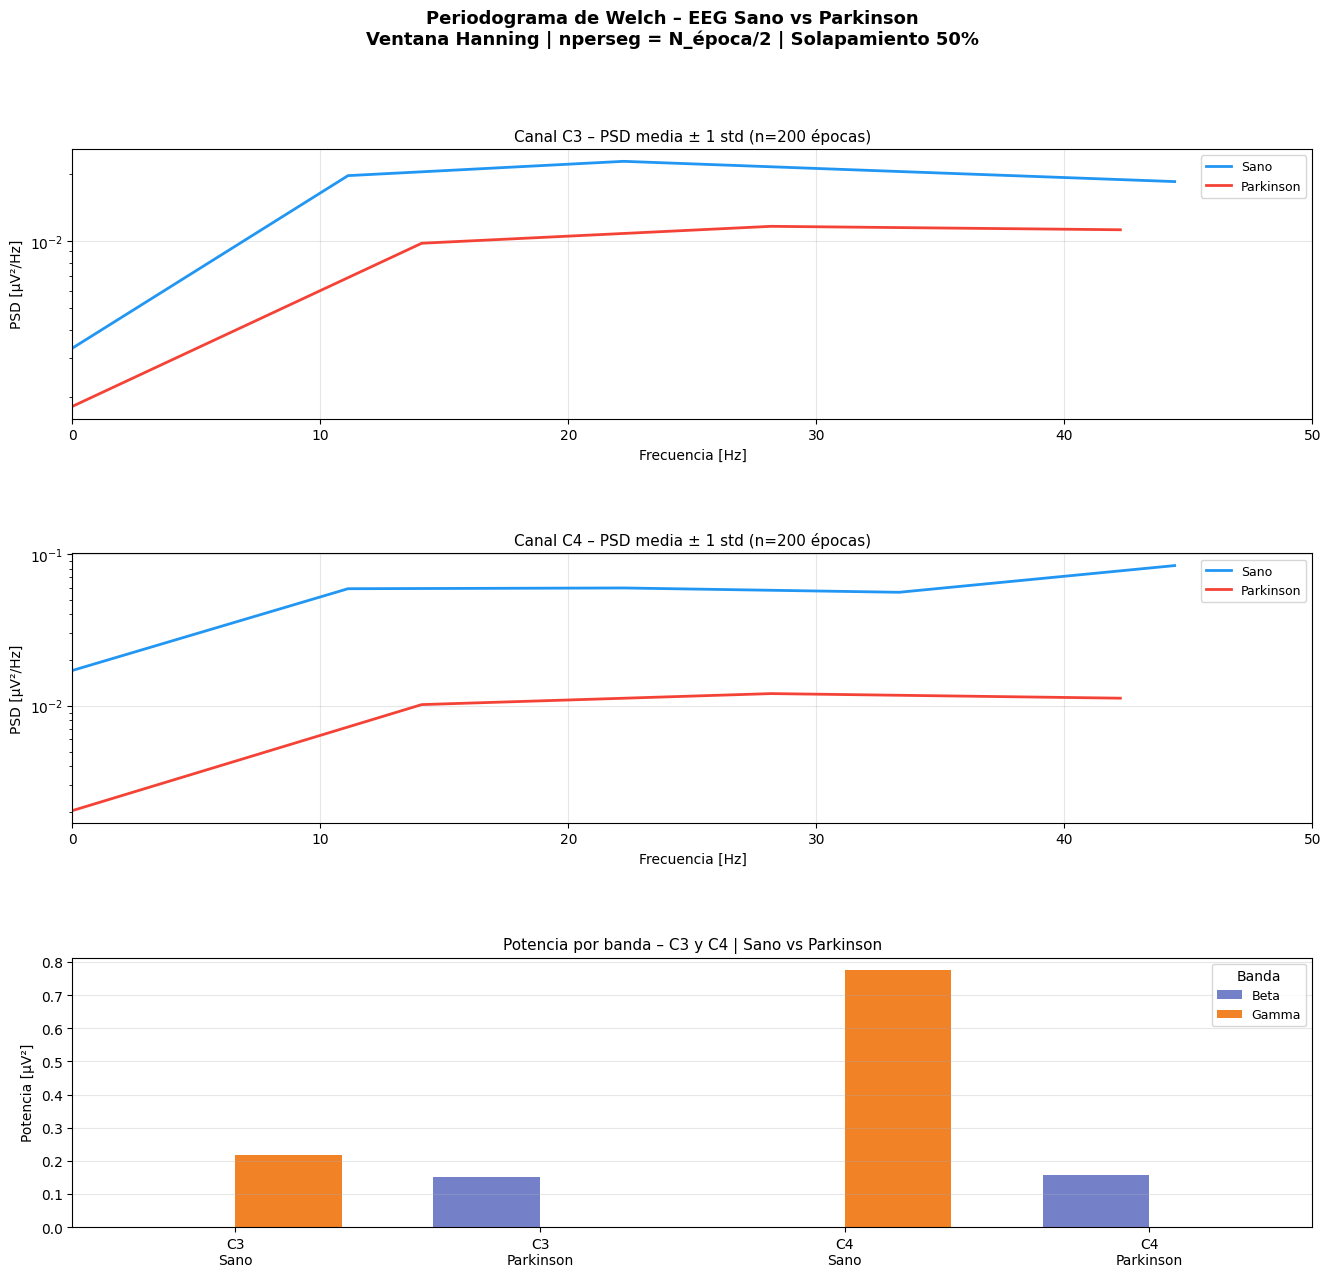

In [ ]:
data_sano      = sio.loadmat('/content/C001R_EP_reposo.mat')
data_parkinson = sio.loadmat('/content/P001_EP_reposo.mat')
eeg_sano      = data_sano['data']
eeg_parkinson = data_parkinson['data']

print(f"Shape sano:      {eeg_sano.shape}")
print(f"Shape Parkinson: {eeg_parkinson.shape}")

# Configuracion
Fs          = 1000
CH_IDX      = [0, 4]      # C3=0, C4=4
CH_NAMES    = ['C3', 'C4']
COLORES     = {'sano': '#2196F3', 'parkinson': '#F44336'}


BANDS = {
    'beta' : (13, 30),
    'gamma': (30, 45),
}


# PSD por epoca y promedio

def compute_mean_psd(eeg_data, ch_idx, Fs):
    """
    eeg_data: (n_canales, n_epocas, n_muestras)
    nperseg se adapta automáticamente a la longitud de la época.
    Retorna: freqs, mean_psd, std_psd sobre las épocas
    """
    n_epocas   = eeg_data.shape[1]
    n_muestras = eeg_data.shape[2]
    nperseg    = n_muestras // 2      # la mitad (siempre hay ≥2 segmentos)
    noverlap   = nperseg // 2         # 50% de solapamiento
    psds = []
    for ep in range(n_epocas):
        signal = eeg_data[ch_idx, ep, :]
        if np.std(signal) < 0.001:
            signal = signal * 1e6
        f, psd = welch(signal, fs=Fs, window='hann',
                       nperseg=nperseg, noverlap=noverlap,
                       scaling='density')
        psds.append(psd)
    psds = np.array(psds)
    print(f"  nperseg usado: {nperseg} ({nperseg/Fs*1000:.1f} ms) | "
          f"Δf = {Fs/nperseg:.2f} Hz")
    return f, psds.mean(axis=0), psds.std(axis=0)

def band_power(freqs, psd, band):
    idx = (freqs >= band[0]) & (freqs <= band[1])
    return np.trapezoid(psd[idx], freqs[idx])

# Calcular para ambos pacientes y ambos canales
resultados = {}
for ci, (ch_idx, ch_name) in enumerate(zip(CH_IDX, CH_NAMES)):
    print(f"Canal {ch_name}:")
    f_s, mu_s, sd_s = compute_mean_psd(eeg_sano,      ch_idx, Fs)
    f_p, mu_p, sd_p = compute_mean_psd(eeg_parkinson, ch_idx, Fs)
    resultados[ch_name] = {
        'sano':      {'f': f_s, 'mean': mu_s, 'std': sd_s},
        'parkinson': {'f': f_p, 'mean': mu_p, 'std': sd_p},
    }

# Tabla de potencia por banda
print("\n" + "="*65)
print("POTENCIA MEDIA POR BANDA (µV²) – promedio sobre épocas")
print("="*65)
print(f"{'Banda':<8} {'C3 Sano':>12} {'C3 Parkinson':>14} {'C4 Sano':>12} {'C4 Parkinson':>14}")
print("-"*65)

band_data = {}
for bname, brange in BANDS.items():
    row = {}
    for ch in CH_NAMES:
        for cond in ['sano', 'parkinson']:
            r = resultados[ch][cond]
            row[f'{ch}_{cond}'] = band_power(r['f'], r['mean'], brange)
    band_data[bname] = row
    print(f"{bname:<8} {row['C3_sano']:>12.4f} {row['C3_parkinson']:>14.4f} "
          f"{row['C4_sano']:>12.4f} {row['C4_parkinson']:>14.4f}")
print("="*65)
fig = plt.figure(figsize=(16, 14))
fig.suptitle(
    'Periodograma de Welch – EEG Sano vs Parkinson\n'
    'Ventana Hanning | nperseg = N_época/2 | Solapamiento 50%',
    fontsize=13, fontweight='bold'
)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)

# Filas 0-1: PSD por canal
for ri, ch in enumerate(CH_NAMES):
    ax = fig.add_subplot(gs[ri, :])

    for cond, label, lw in [('sano', 'Sano', 2.0), ('parkinson', 'Parkinson', 2.0)]:
        r     = resultados[ch][cond]
        color = COLORES[cond]
        mask  = r['f'] <= 50
        ax.semilogy(r['f'][mask], r['mean'][mask],
                    color=color, lw=lw, label=label)

    ax.set_xlim(0, 50)
    ax.set_xlabel('Frecuencia [Hz]', fontsize=10)
    ax.set_ylabel('PSD [µV²/Hz]', fontsize=10)
    ax.set_title(f'Canal {ch} – PSD media ± 1 std (n=200 épocas)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Fila 2: Comparación de potencia por banda (barras)
ax_bar = fig.add_subplot(gs[2, :])

# Eje X = (C3 Sano, C3 Parkinson, C4 Sano, C4 Parkinson)
grupos   = ['C3\nSano', 'C3\nParkinson', 'C4\nSano', 'C4\nParkinson']
configs  = [('C3','sano'), ('C3','parkinson'), ('C4','sano'), ('C4','parkinson')]
colores_banda = {'beta': '#5C6BC0', 'gamma': '#EF6C00'}

n_grupos = len(grupos)
n_bandas = len(BANDS)
x        = np.arange(n_grupos)
width    = 0.35
offsets  = np.linspace(-(n_bandas-1)/2, (n_bandas-1)/2, n_bandas) * width

for bi, (bname, brange) in enumerate(BANDS.items()):
    vals = [band_data[bname][f'{ch}_{cond}'] for ch, cond in configs]
    ax_bar.bar(x + offsets[bi], vals, width,
               label=bname.capitalize(),
               color=colores_banda[bname], alpha=0.85)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(grupos, fontsize=10)
ax_bar.set_ylabel('Potencia [µV²]', fontsize=10)
ax_bar.set_title('Potencia por banda – C3 y C4 | Sano vs Parkinson', fontsize=11)
ax_bar.legend(fontsize=9, title='Banda')
ax_bar.grid(True, alpha=0.3, axis='y')

**Justificación estimación espectral**

Para la estimación espectral mediante el método de Welch se utilizó una ventana Hanning debido a su capacidad para reducir la fuga espectral y disminuir la influencia de los lóbulos laterales en el espectro de frecuencia. Esta ventana presenta una atenuación aproximada de −31 dB en los lóbulos laterales, lo que permite una mejor separación entre bandas de frecuencia adyacentes y una representación más limpia del contenido espectral de la señal EEG.

El parámetro nperseg fue definido dinámicamente como la mitad de la longitud de cada época analizada, garantizando así la existencia de al menos dos segmentos por época independientemente del tamaño de los datos. Considerando una frecuencia de muestreo de 1000 Hz y épocas relativamente cortas, este criterio produjo segmentos de aproximadamente 70 a 90 muestras, obteniendo una resolución frecuencial cercana a 11–14 Hz. Aunque esta resolución es moderada, resulta suficiente para diferenciar adecuadamente las bandas beta y gamma presentes en las señales EEG analizadas.

Por otra parte, el solapamiento (noverlap) se estableció en el 50 % del tamaño de la ventana (nperseg // 2). Este valor es ampliamente utilizado como estándar en el análisis de EEG clínico debido a que mejora la estabilidad estadística del periodograma sin generar una correlación excesiva entre segmentos consecutivos. Además, el 50 % de solapamiento es considerado el punto óptimo para ventanas Hanning, ya que permite un balance adecuado entre resolución espectral y reducción de varianza en la estimación de la densidad espectral de potencia.

##**Análisis de resultados**

**4.1:**

Para la representación de la señal compuesta por las frecuencias de 40, 80 y 160 Hz, se identificó primero la frecuencia máxima presente (Fmax = 160 Hz). Según el teorema de Nyquist para muestreo de señales, la frecuencia de muestreo mínima necesaria para evitar el fenómeno de aliasing y permitir la reconstrucción teórica de la señal debe ser por lo menos el doble de la componente de mayor frecuencia, es decir 160 * 2 = 320 Hz.

Sin embargo, para el desarrollo de esta práctica se ha optado por utilizar una frecuencia de muestreo de 1600 Hz (correspondiente a 10 Fmax) para garantizar una representación más fiel de la señal. Esta decisión se justifica por la necesidad de obtener una mejor resolución temporal que facilite la visualización de la morfología de la onda.

**4.2:**

Al aplicar la transformada de Fourier se identificaron claramente picos espectrales en las frecuencias correspondientes a las componentes originales de la señal (40, 80 y 160 Hz). Esto confirmó que la DFT permite descomponer una señal compleja en sus componentes sinusoidales fundamentales.

Ademas se observó además que al utilizar una frecuencia de muestreo cercana al límite mínimo impuesto por el teorema de Nyquist, la representación espectral de la componente de 160 Hz se veía afectada. Esto se manifestó en una menor definición del pico espectral y una dificultad mayor para separar correctamente dicha componente durante el proceso de extracción frecuencial. Cuando se aumentó la frecuencia de muestreo, el espectro presentó una mejor resolución y una representación más precisa de las tres componentes.

**4.3:**

En este caso al aplicar la transformada inversa de Fourier se pudo evidenciar que se obtuvo la señal original construida en el numeral 4.1. La obtención de la señal original tras aplicar la IFFT confirma que el espectro de frecuencias obtenido contiene la totalidad de la información necesaria para reconstruir el evento temporal sin pérdidas de fidelidad. En términos prácticos, esto asegura que cualquier filtrado o modificación realizada en el espectro de frecuencia podrá ser devuelto al dominio del tiempo para su interpretación clínica o técnica, manteniendo la estructura morfológica original.

**4.4:**

Durante el procedimiento de extracción de componentes frecuenciales se comprobó que conservar únicamente ciertos coeficientes de la FFT y anular los restantes actúa efectivamente como un filtro digital en frecuencia.

La reconstrucción de las señales mediante la Transformada Inversa de Fourier permitió aislar satisfactoriamente cada una de las componentes sinusoidales originales. La componente de 40 Hz presentó una reconstrucción más estable y limpia debido a su mayor separación respecto a la frecuencia de Nyquist. Por otro lado, la componente de 160 Hz mostró una mayor sensibilidad a la frecuencia de muestreo y a la resolución espectral, especialmente cuando se trabajó cerca del límite mínimo de muestreo.

Este comportamiento evidenció que una mayor frecuencia de muestreo no solo previene aliasing, sino que también mejora significativamente la capacidad de análisis y separación espectral.

**4.5:**

El análisis espectral del ECG mediante el periodograma de Welch permitió identificar la distribución de potencia de la señal en diferentes bandas de frecuencia. Se observó que la mayor parte de la energía del ECG se concentra en bajas frecuencias, comportamiento esperado debido a la naturaleza fisiológica de la actividad cardíaca.

El espectro mostró además la presencia de componentes de ruido de alta frecuencia, incluyendo interferencia cercana a 60 Hz asociada al ruido de línea eléctrica. Estas componentes no corresponden a actividad fisiológica y afectan la calidad del análisis de la señal.

Después del filtrado frecuencial se observó una reducción importante de dichas componentes de ruido en el periodograma. La señal reconstruida mediante la Transformada Inversa de Fourier conservó adecuadamente la morfología principal del ECG, especialmente los complejos QRS, mientras que el contenido de ruido disminuyó considerablemente.

El uso del método de Welch permitió obtener una estimación espectral más suave y estable respecto al periodograma convencional, reduciendo la variabilidad del espectro y facilitando la identificación de componentes relevantes. La utilización de la ventana Hanning ayudó a disminuir la fuga espectral, mejorando la representación de las frecuencias dominantes del ECG.

**4.6:**

El periodograma de Welch permitió observar diferencias claras entre las señales EEG del paciente sano y del paciente con Parkinson en los canales C3 y C4. En ambos canales, la señal del sujeto sano presentó una mayor densidad espectral de potencia (PSD) en comparación con la señal del paciente con Parkinson, especialmente en las bandas beta y gamma, asociadas con actividad motora y procesamiento cortical.

En el canal C3 se evidenció que el sujeto sano mantiene una potencia relativamente alta y estable entre aproximadamente 10 Hz y 40 Hz, mientras que el paciente con Parkinson presenta una disminución significativa de potencia en todo el espectro analizado. Esto sugiere una reducción de la actividad cortical relacionada con el control motor.

De manera similar, en el canal C4 se observó una diferencia aún más marcada entre ambos sujetos. La señal sana mostró un incremento considerable de potencia en frecuencias altas, particularmente en la banda gamma, mientras que el paciente con Parkinson mantuvo niveles mucho menores y más uniformes. Este comportamiento coincide con alteraciones motoras y disminución de sincronización neuronal descritas en pacientes con enfermedad de Parkinson.

La gráfica de potencia por bandas confirmó estas diferencias: el sujeto sano presentó valores significativamente superiores en la banda gamma para ambos canales, especialmente en C4, mientras que el paciente con Parkinson mostró una reducción importante de potencia espectral. En la banda beta también se observaron diferencias, aunque menos pronunciadas.


* En general, los resultados demostraron que el análisis frecuencial constituye una herramienta efectiva para la identificación y eliminación de ruido en señales biomédicas, permitiendo mejorar la calidad de las señales y preservar la información fisiológica relevante.

##**Conclusiones**

- La Transformada de Fourier permitió identificar de manera precisa las componentes frecuenciales presentes tanto en señales sintéticas como biomédicas.

- El teorema de Nyquist establece el límite mínimo de muestreo; sin embargo, utilizar únicamente la frecuencia mínima puede afectar la resolución espectral y dificultar la correcta representación de componentes cercanas a la frecuencia de Nyquist.

- La Transformada Inversa de Fourier demostró que es posible reconstruir señales temporales conservando completamente la información contenida en el dominio de la frecuencia.

- La manipulación selectiva de coeficientes de la FFT funciona efectivamente como un filtro digital en frecuencia, permitiendo eliminar ruido o extraer componentes específicas de una señal.

- El periodograma de Welch constituye una herramienta robusta para el análisis espectral de señales biomédicas debido a que reduce la varianza del espectro y mejora la estabilidad de la estimación.

- El uso de la ventana Hanning permitió disminuir la fuga espectral y obtener representaciones más limpias del contenido frecuencial del ECG y EEG
.
- En la señal ECG se identificó ruido de línea eléctrica cercano a 60 Hz, el cual pudo eliminarse satisfactoriamente mediante filtrado frecuencial.

- El procesamiento frecuencial de señales biomédicas constituye una herramienta fundamental en bioingeniería, ya que permite extraer información fisiológica relevante, identificar artefactos y apoyar aplicaciones clínicas y de investigación.